In [1]:
# Import libraries
import sys
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr

import torch
import lightning as pl
from chemprop import data, featurizers, utils
from chemprop.models.utils import load_model

In [2]:
# Setup paths
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [3]:
# Constants
RANDOM_SEED = 42
pl.seed_everything(RANDOM_SEED, workers=True)

smiles_column = 'SMILES_clean'
target_column = ['logTg']

descriptor_list = [
    'Moleculer Weight',
    'Proxy for Free Volume',
    'Rotatable Bonds',
    'Aromatic Rings',
    'Topological Polar Surface Area',
    'H-Bond Donors',
    'H-Bond Acceptors'
]

figs_dir = PROJECT_ROOT / "figs"
figs_dir.mkdir(exist_ok=True)
ensemble_dir = PROJECT_ROOT / "models"

Seed set to 42


## Load Data

In [4]:
# Load training data
df_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "training_data.csv")

train_smis = df_train[smiles_column].values
train_targets = df_train[target_column].values.flatten()
train_descriptors = df_train[descriptor_list].values

print(f"Train samples: {len(train_smis)}")
print(f"Descriptors shape: {train_descriptors.shape}")

Train samples: 683
Descriptors shape: (683, 7)


In [5]:
# Load test data
df_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test_data.csv")

test_smis = df_test[smiles_column].values
test_targets = df_test[target_column].values.flatten()
test_descriptors = df_test[descriptor_list].values

print(f"Test samples: {len(test_smis)}")
print(f"Descriptors shape: {test_descriptors.shape}")

Test samples: 219
Descriptors shape: (219, 7)


In [6]:
# Load train/val split indices from ensemble training (using fold 0)
with open(ensemble_dir / "train_data_split_indexes.pkl", "rb") as f:
    train_idxs_dict = pickle.load(f)

with open(ensemble_dir / "validation_data_split_indexes.pkl", "rb") as f:
    val_idxs_dict = pickle.load(f)

# Use fold 0 for analysis
fold = 0
train_idxs = train_idxs_dict[fold]
val_idxs = val_idxs_dict[fold]

print(f"Fold {fold+1}: Train indices: {len(train_idxs)}, Val indices: {len(val_idxs)}")

Fold 1: Train indices: 614, Val indices: 69


## Extract D-MPNN embeddings

Extract learned representations from the message-passing layers (before the final FFN).

In [7]:
def extract_embeddings(model, smiles_list, batch_size=64):
    """
    Extract molecular embeddings from MPNN model (after message passing + aggregation).
    
    Returns:
        embeddings: np.ndarray of shape (n_samples, embedding_dim)
    """
    model.eval()
    
    # Convert SMILES to molecules
    mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in smiles_list]
    
    # Create minimal datapoints (no targets needed for inference)
    datapoints = [data.MoleculeDatapoint(mol, y=np.array([0.0])) for mol in mols]
    
    featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
    dataset = data.MoleculeDataset(datapoints, featurizer)
    
    loader = data.build_dataloader(
        dataset,
        batch_size=batch_size,
        num_workers=0,
        shuffle=False
    )
    
    embeddings = []
    
    with torch.no_grad():
        for batch in loader:
            bmg = batch.bmg
            
            # Extract embeddings: run through message passing + aggregation only
            # Skip the final FFN predictor
            # Access via model's internal structure (chemprop models expose these)
            H_v = model.message_passing(bmg)
            H = model.agg(H_v, bmg.batch)
            
            embeddings.append(H.cpu().numpy())
    
    return np.vstack(embeddings)

In [8]:
# Load one model WITHOUT descriptors (to get pure GNN embeddings)
# Use fold_1, seed_1 (first model)
no_desc_dir = ensemble_dir / "ensemble_without_descriptors"
model_path = sorted(no_desc_dir.glob(f"fold_{fold+1}/seed_*/best_model.ckpt"))[0]
model_no_desc = load_model(model_path)

print(f"Loaded model from: {model_path}")
print(f"Message passing output dim: {model_no_desc.message_passing.output_dim}")

Loaded model from: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/models/ensemble_without_descriptors/fold_1/seed_104832472/best_model.ckpt
Message passing output dim: 300


In [9]:
# Extract embeddings for train set
print("Extracting train embeddings...")
train_embeddings = extract_embeddings(model_no_desc, train_smis)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Mean: {train_embeddings.mean():.4f}, Std: {train_embeddings.std():.4f}")

Extracting train embeddings...
Train embeddings shape: (683, 300)
Mean: 0.0752, Std: 0.1104


In [10]:
# Extract embeddings for test set
print("Extracting test embeddings...")
test_embeddings = extract_embeddings(model_no_desc, test_smis)

print(f"Test embeddings shape: {test_embeddings.shape}")
print(f"Mean: {test_embeddings.mean():.4f}, Std: {test_embeddings.std():.4f}")

Extracting test embeddings...
Test embeddings shape: (219, 300)
Mean: 0.0751, Std: 0.1102


## (A) Embedding → Descriptor Predictability

Train Ridge regression models to predict each descriptor from GNN embeddings.

**Interpretation:**
- **High R² (>0.7)**: Descriptor is redundant - GNN already learned this information
- **Low R² (<0.3)**: Descriptor provides unique/complementary information
- **Medium R² (0.3-0.7)**: Partially captured by GNN

In [11]:
# Split train data into actual train/val using same indices as model training
X_train_emb = train_embeddings[train_idxs]
X_val_emb = train_embeddings[val_idxs]

y_train_desc = train_descriptors[train_idxs]
y_val_desc = train_descriptors[val_idxs]

print(f"Train embeddings: {X_train_emb.shape}, Val embeddings: {X_val_emb.shape}")

Train embeddings: (614, 300), Val embeddings: (69, 300)


In [12]:
# Train Ridge models to predict each descriptor from embeddings
predictability_results = []

for i, desc_name in enumerate(descriptor_list):
    # Train Ridge regression
    model = Ridge(alpha=1.0)
    model.fit(X_train_emb, y_train_desc[:, i])
    
    # Predict on val and test
    val_pred = model.predict(X_val_emb)
    test_pred = model.predict(test_embeddings)
    
    # Compute R² scores
    val_r2 = r2_score(y_val_desc[:, i], val_pred)
    test_r2 = r2_score(test_descriptors[:, i], test_pred)
    
    predictability_results.append({
        'Descriptor': desc_name,
        'Val R²': val_r2,
        'Test R²': test_r2,
    })

predictability_df = pd.DataFrame(predictability_results)

print("\n" + "="*80)
print("TABLE A: Embedding → Descriptor Predictability (R²)")
print("="*80)
print(predictability_df.to_string(index=False))

# Save to CSV
output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "descriptor_predictability.csv"
predictability_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


TABLE A: Embedding → Descriptor Predictability (R²)
                    Descriptor   Val R²  Test R²
              Moleculer Weight 0.782727 0.758234
         Proxy for Free Volume 0.492923 0.579143
               Rotatable Bonds 0.676906 0.653073
                Aromatic Rings 0.846948 0.813514
Topological Polar Surface Area 0.652783 0.629351
                 H-Bond Donors 0.489203 0.423724
              H-Bond Acceptors 0.782801 0.725624

Saved to: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/data/processed/descriptor_predictability.csv


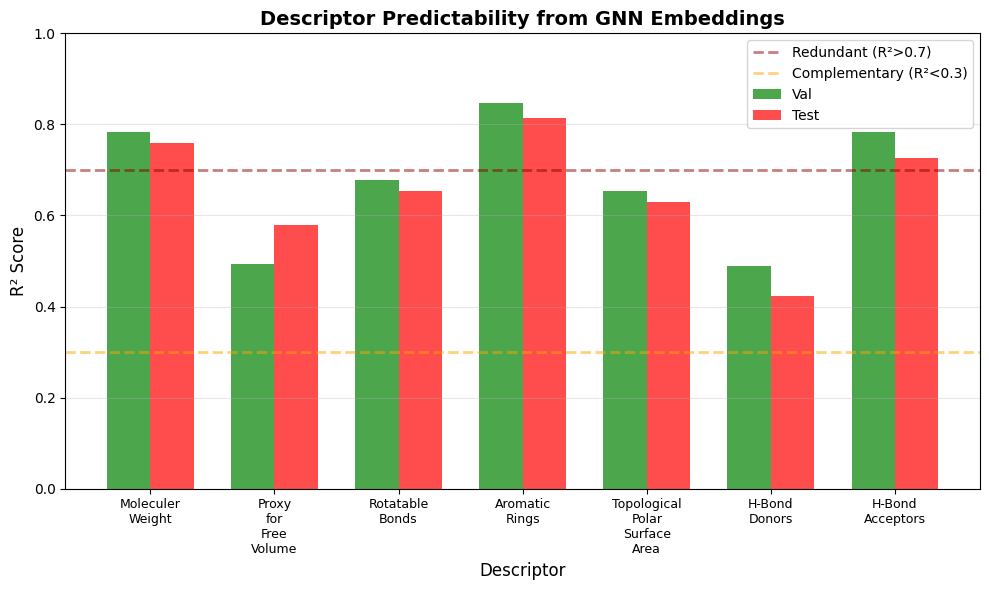

In [13]:
# Visualize predictability
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(descriptor_list))
width = 0.35

ax.bar(x - width/2, predictability_df['Val R²'], width, label='Val', color='green', alpha=0.7)
ax.bar(x + width/2, predictability_df['Test R²'], width, label='Test', color='red', alpha=0.7)

# Add horizontal lines for interpretation
ax.axhline(y=0.7, color='darkred', linestyle='--', linewidth=2, alpha=0.5, label='Redundant (R²>0.7)')
ax.axhline(y=0.3, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Complementary (R²<0.3)')

ax.set_xlabel('Descriptor', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Descriptor Predictability from GNN Embeddings', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([d.replace(' ', '\n') for d in descriptor_list], fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(figs_dir / "descriptor_predictability_barplot.png", dpi=300, bbox_inches='tight')
plt.show()

## (B) Residual Analysis

Test if descriptors explain prediction errors from embedding-only models.

**Analysis:**
1. Get predictions from WITHOUT descriptors ensemble
2. Compute residuals (true - predicted)
3. Correlate residuals with each descriptor
4. Check if WITH descriptors model fixes systematic errors

In [14]:
# Load WITHOUT descriptors ensemble (embedding-only) - use fold 0, all 100 seeds
no_desc_dir = ensemble_dir / "ensemble_without_descriptors"
no_desc_models = []
model_ckpt_paths = sorted(no_desc_dir.glob(f"fold_{fold+1}/seed_*/best_model.ckpt"))
for ckpt_path in model_ckpt_paths:
    no_desc_models.append(load_model(ckpt_path))

print(f"Loaded {len(no_desc_models)} models WITHOUT descriptors (fold {fold+1})")

Loaded 100 models WITHOUT descriptors (fold 1)


In [15]:
# Load WITH descriptors ensemble - use fold 0, all 100 seeds
with_desc_dir = ensemble_dir / "ensemble_with_descriptors"
with_desc_models = []
model_ckpt_paths = sorted(with_desc_dir.glob(f"fold_{fold+1}/seed_*/best_model.ckpt"))
for ckpt_path in model_ckpt_paths:
    with_desc_models.append(load_model(ckpt_path))

print(f"Loaded {len(with_desc_models)} models WITH descriptors (fold {fold+1})")

Loaded 100 models WITH descriptors (fold 1)


In [16]:
def ensemble_predict(models, smiles_list, descriptors=None, train_mols=None, train_ys=None, train_descriptors=None):
    """
    Get ensemble predictions (mean across all models).
    Uses PyTorch Lightning trainer for consistency with ensemble_N_sweep notebook.
    """
    # Convert SMILES to molecules
    mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in smiles_list]
    
    featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
    
    # Prepare datapoints
    if descriptors is not None:
        # Need train data for descriptor normalization
        train_data_w_desc = [
            data.MoleculeDatapoint(train_mols[i], train_ys[i], x_d=train_descriptors[i]) 
            for i in range(len(train_mols))
        ]
        train_dset_w_desc = data.MoleculeDataset(train_data_w_desc, featurizer)
        descriptors_scaler = train_dset_w_desc.normalize_inputs("X_d")
        
        test_data_w_desc = [
            data.MoleculeDatapoint(mols[i], np.array([0.0]), x_d=descriptors[i]) 
            for i in range(len(mols))
        ]
        test_dset_w_desc = data.MoleculeDataset(test_data_w_desc, featurizer)
        test_dset_w_desc.normalize_inputs("X_d", descriptors_scaler)
        
        test_loader = data.build_dataloader(
            test_dset_w_desc,
            batch_size=len(test_dset_w_desc),
            num_workers=0,
            shuffle=False
        )
    else:
        test_data = [
            data.MoleculeDatapoint(mols[i], np.array([0.0])) 
            for i in range(len(mols))
        ]
        test_dset = data.MoleculeDataset(test_data, featurizer)
        test_loader = data.build_dataloader(
            test_dset,
            batch_size=len(test_dset),
            num_workers=0,
            shuffle=False
        )
    
    # Get predictions using PyTorch Lightning trainer
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False
    )
    
    all_preds = []
    for model in models:
        model.eval()
        pred = trainer.predict(model, test_loader)
        preds = torch.cat(pred).cpu().numpy().flatten()
        all_preds.append(preds)
    
    # Return mean prediction across ensemble
    return np.mean(all_preds, axis=0)

In [17]:
# Prepare train molecules and targets for descriptor normalization
train_mols = [utils.make_mol(smi, keep_h=False, add_h=False) for smi in train_smis[train_idxs]]
train_ys_subset = train_targets[train_idxs]
train_desc_subset = train_descriptors[train_idxs]

# Get predictions on test set
print("Getting ensemble predictions on test set...")

test_preds_no_desc = ensemble_predict(
    no_desc_models, test_smis, descriptors=None,
    train_mols=train_mols, train_ys=train_ys_subset
)

test_preds_with_desc = ensemble_predict(
    with_desc_models, test_smis, descriptors=test_descriptors,
    train_mols=train_mols, train_ys=train_ys_subset, train_descriptors=train_desc_subset
)

print(f"Predictions WITHOUT descriptors: {test_preds_no_desc.shape}")
print(f"Predictions WITH descriptors: {test_preds_with_desc.shape}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' 

Getting ensemble predictions on test set...


/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVI

Predictions WITHOUT descriptors: (219,)
Predictions WITH descriptors: (219,)


In [18]:
# Compute residuals
residuals_no_desc = test_targets - test_preds_no_desc
residuals_with_desc = test_targets - test_preds_with_desc

# Compute errors
rmse_no_desc = np.sqrt(np.mean(residuals_no_desc**2))
rmse_with_desc = np.sqrt(np.mean(residuals_with_desc**2))

print(f"\nTest RMSE (WITHOUT descriptors): {rmse_no_desc:.4f}")
print(f"Test RMSE (WITH descriptors): {rmse_with_desc:.4f}")
print(f"Improvement: {rmse_no_desc - rmse_with_desc:.4f} ({100*(rmse_no_desc - rmse_with_desc)/rmse_no_desc:.2f}%)")


Test RMSE (WITHOUT descriptors): 0.0673
Test RMSE (WITH descriptors): 0.0698
Improvement: -0.0025 (-3.66%)


In [19]:
# Correlate residuals with descriptors
residual_correlations = []

for i, desc_name in enumerate(descriptor_list):
    # Pearson correlation
    pearson_r, pearson_p = pearsonr(test_descriptors[:, i], residuals_no_desc)
    
    # Spearman correlation (non-parametric)
    spearman_r, spearman_p = spearmanr(test_descriptors[:, i], residuals_no_desc)
    
    residual_correlations.append({
        'Descriptor': desc_name,
        'Pearson r': pearson_r,
        'Pearson p-value': pearson_p,
        'Spearman ρ': spearman_r,
        'Spearman p-value': spearman_p,
        'Significant (p<0.05)': 'Yes' if pearson_p < 0.05 else 'No'
    })

residual_corr_df = pd.DataFrame(residual_correlations)

print("\n" + "="*80)
print("TABLE B: Descriptor Correlation with Embedding-Only Model Residuals")
print("="*80)
print(residual_corr_df.to_string(index=False))

# Save to CSV
output_path = output_dir / "residual_correlations.csv"
residual_corr_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


TABLE B: Descriptor Correlation with Embedding-Only Model Residuals
                    Descriptor  Pearson r  Pearson p-value  Spearman ρ  Spearman p-value Significant (p<0.05)
              Moleculer Weight   0.154186         0.022469    0.224761          0.000808                  Yes
         Proxy for Free Volume  -0.108184         0.110377   -0.192357          0.004276                   No
               Rotatable Bonds   0.106935         0.114573    0.191051          0.004550                   No
                Aromatic Rings   0.159565         0.018128    0.240420          0.000330                  Yes
Topological Polar Surface Area   0.030638         0.652055    0.078185          0.249248                   No
                 H-Bond Donors   0.110073         0.104257    0.115839          0.087227                   No
              H-Bond Acceptors   0.008982         0.894859    0.101548          0.134122                   No

Saved to: /home/vidit/projects/Polymer-Glass-Trans

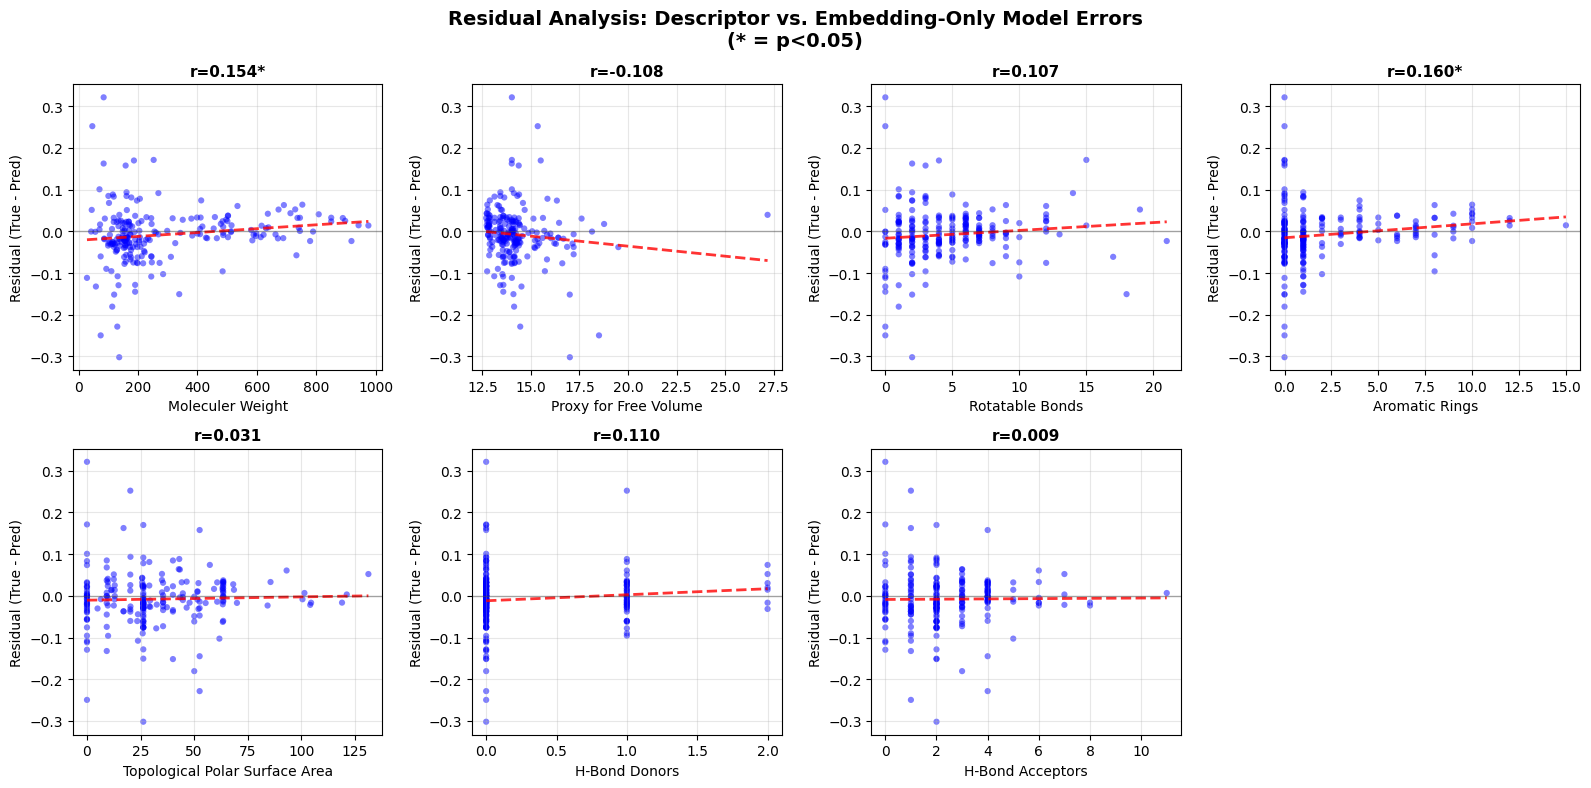

In [20]:
# Visualize residual correlations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, desc_name in enumerate(descriptor_list):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(test_descriptors[:, i], residuals_no_desc, 
               alpha=0.5, s=20, color='blue', edgecolor='none')
    
    # Add regression line
    z = np.polyfit(test_descriptors[:, i], residuals_no_desc, 1)
    p = np.poly1d(z)
    x_line = np.linspace(test_descriptors[:, i].min(), test_descriptors[:, i].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    # Labels
    ax.set_xlabel(desc_name, fontsize=10)
    ax.set_ylabel('Residual (True - Pred)', fontsize=10)
    
    # Add correlation info
    r = residual_corr_df.loc[i, 'Pearson r']
    p_val = residual_corr_df.loc[i, 'Pearson p-value']
    sig = "*" if p_val < 0.05 else ""
    ax.set_title(f"r={r:.3f}{sig}", fontsize=11, fontweight='bold')
    
    ax.grid(True, alpha=0.3)

# Hide the last empty subplot
axes[-1].axis('off')

plt.suptitle('Residual Analysis: Descriptor vs. Embedding-Only Model Errors\n(* = p<0.05)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figs_dir / "residual_correlation_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

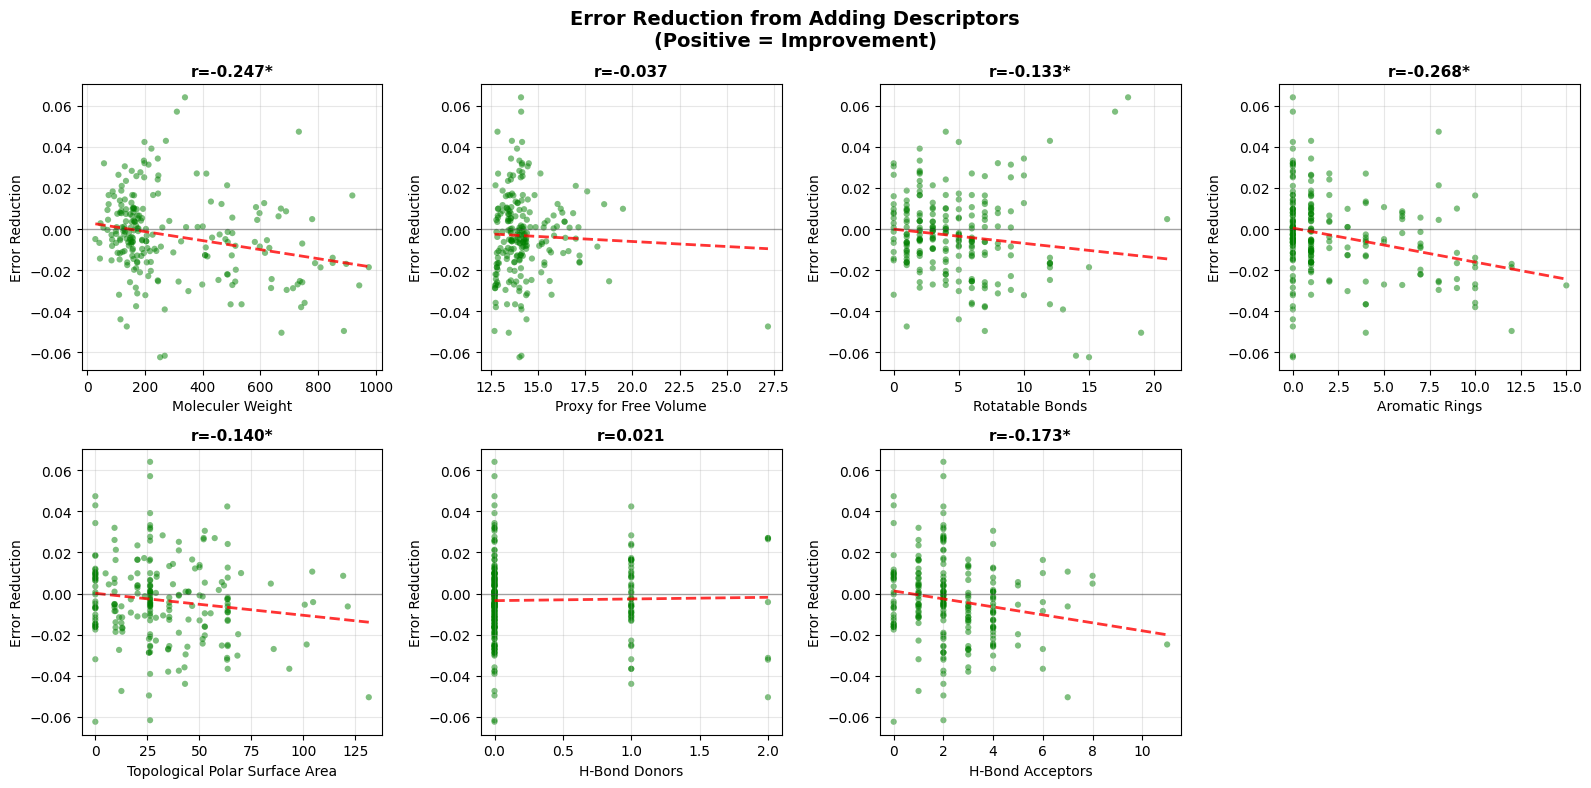

In [21]:
# Visualize absolute error reduction by descriptor value
abs_errors_no_desc = np.abs(residuals_no_desc)
abs_errors_with_desc = np.abs(residuals_with_desc)
error_reduction = abs_errors_no_desc - abs_errors_with_desc

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, desc_name in enumerate(descriptor_list):
    ax = axes[i]
    
    # Scatter plot: descriptor vs error reduction
    ax.scatter(test_descriptors[:, i], error_reduction,
               alpha=0.5, s=20, color='green', edgecolor='none')
    
    # Add regression line
    z = np.polyfit(test_descriptors[:, i], error_reduction, 1)
    p = np.poly1d(z)
    x_line = np.linspace(test_descriptors[:, i].min(), test_descriptors[:, i].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    # Add zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    # Labels
    ax.set_xlabel(desc_name, fontsize=10)
    ax.set_ylabel('Error Reduction', fontsize=10)
    
    # Correlation
    r, p_val = pearsonr(test_descriptors[:, i], error_reduction)
    sig = "*" if p_val < 0.05 else ""
    ax.set_title(f"r={r:.3f}{sig}", fontsize=11, fontweight='bold')
    
    ax.grid(True, alpha=0.3)

# Hide last subplot
axes[-1].axis('off')

plt.suptitle('Error Reduction from Adding Descriptors\n(Positive = Improvement)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(figs_dir / "error_reduction_by_descriptor.png", dpi=300, bbox_inches='tight')
plt.show()

## (C) Written Conclusion

Synthesize findings for manuscript supplement.

In [22]:
# Identify complementary vs redundant descriptors
complementary = predictability_df[predictability_df['Test R²'] < 0.3]['Descriptor'].tolist()
redundant = predictability_df[predictability_df['Test R²'] > 0.7]['Descriptor'].tolist()
partial = predictability_df[
    (predictability_df['Test R²'] >= 0.3) & (predictability_df['Test R²'] <= 0.7)
]['Descriptor'].tolist()

# Identify descriptors significantly correlated with residuals
significant_residual_corr = residual_corr_df[
    residual_corr_df['Significant (p<0.05)'] == 'Yes'
]['Descriptor'].tolist()

print("\n" + "="*80)
print("DESCRIPTOR COMPLEMENTARITY SUMMARY")
print("="*80)
print(f"\nComplementary descriptors (R² < 0.3): {len(complementary)}")
for desc in complementary:
    print(f"  - {desc}")

print(f"\nPartially captured (0.3 ≤ R² ≤ 0.7): {len(partial)}")
for desc in partial:
    print(f"  - {desc}")

print(f"\nRedundant descriptors (R² > 0.7): {len(redundant)}")
for desc in redundant:
    print(f"  - {desc}")

print(f"\nDescriptors correlated with residuals (p < 0.05): {len(significant_residual_corr)}")
for desc in significant_residual_corr:
    r_val = residual_corr_df[residual_corr_df['Descriptor'] == desc]['Pearson r'].values[0]
    print(f"  - {desc} (r = {r_val:.3f})")


DESCRIPTOR COMPLEMENTARITY SUMMARY

Complementary descriptors (R² < 0.3): 0

Partially captured (0.3 ≤ R² ≤ 0.7): 4
  - Proxy for Free Volume
  - Rotatable Bonds
  - Topological Polar Surface Area
  - H-Bond Donors

Redundant descriptors (R² > 0.7): 3
  - Moleculer Weight
  - Aromatic Rings
  - H-Bond Acceptors

Descriptors correlated with residuals (p < 0.05): 2
  - Moleculer Weight (r = 0.154)
  - Aromatic Rings (r = 0.160)


In [ ]:
# Generate written conclusion
conclusion = f"""
DESCRIPTOR COMPLEMENTARITY ANALYSIS - MANUSCRIPT TEXT
=====================================================

To assess whether molecular descriptors provide complementary information to the 
graph neural network embeddings, we performed two analyses: (1) descriptor 
predictability from embeddings and (2) residual correlation analysis.

PREDICTABILITY ANALYSIS:
We trained Ridge regression models to predict each of the 7 molecular descriptors 
from the learned GNN embeddings (300-dimensional representations after message 
passing and aggregation). Out of {len(descriptor_list)} descriptors:

- {len(complementary)} descriptor(s) showed LOW predictability (R² < 0.3), 
  indicating they provide COMPLEMENTARY information not captured by the GNN:
  {', '.join(complementary) if complementary else 'None'}

- {len(partial)} descriptor(s) showed MODERATE predictability (0.3 ≤ R² ≤ 0.7),
  suggesting partial overlap with GNN-learned features:
  {', '.join(partial) if partial else 'None'}

- {len(redundant)} descriptor(s) showed HIGH predictability (R² > 0.7),
  indicating they are largely REDUNDANT with GNN embeddings:
  {', '.join(redundant) if redundant else 'None'}

RESIDUAL ANALYSIS:
We correlated each descriptor with prediction residuals from the embedding-only
model (ensemble WITHOUT descriptors). {len(significant_residual_corr)} descriptor(s) 
showed significant correlation (p < 0.05) with prediction errors:
{chr(10).join(f'  - {desc} (r = {residual_corr_df[residual_corr_df["Descriptor"] == desc]["Pearson r"].values[0]:.3f})' for desc in significant_residual_corr) if significant_residual_corr else '  None'}

These descriptors explain systematic errors made by the embedding-only model,
supporting their complementary role in prediction.

print(conclusion)


DESCRIPTOR COMPLEMENTARITY ANALYSIS - MANUSCRIPT TEXT

To assess whether molecular descriptors provide complementary information to the 
graph neural network embeddings, we performed two analyses: (1) descriptor 
predictability from embeddings and (2) residual correlation analysis.

PREDICTABILITY ANALYSIS:
We trained Ridge regression models to predict each of the 7 molecular descriptors 
from the learned GNN embeddings (300-dimensional representations after message 
passing and aggregation). Out of 7 descriptors:

- 0 descriptor(s) showed LOW predictability (R² < 0.3), 
  indicating they provide COMPLEMENTARY information not captured by the GNN:
  None

- 4 descriptor(s) showed MODERATE predictability (0.3 ≤ R² ≤ 0.7),
  suggesting partial overlap with GNN-learned features:
  Proxy for Free Volume, Rotatable Bonds, Topological Polar Surface Area, H-Bond Donors

- 3 descriptor(s) showed HIGH predictability (R² > 0.7),
  indicating they are largely REDUNDANT with GNN embeddings:
  Mole